# Emerging Jets — Preprocessing FINALE (best-of-three)

Notebook di preprocessing **unico e definitivo** per il progetto *Emerging Jets Anomaly Detection*.
Mette insieme le scelte migliori delle tre pipeline sviluppate (Alessio, Daniele, Andrea):

| Da dove arriva | Cosa prendiamo |
|---|---|
| **Daniele** (modulo) | clip di sicurezza **±10σ scelto a priori** (anti data-leak), pipeline ordinata e ispezionabile, 3 rappresentazioni + grafi in due spazi |
| **Andrea** | uso di **feature jet + track**, **diagnostica anti-leakage** (AUC per singola feature + baseline logistic regression), aggregati robusti (median, q90) |
| **Alessio** | profondità di **EDA**, uso di `d0_log1p` (coda compressa), gestione esplicita del **sentinella −999** |

### Principi metodologici (validi per tutto il notebook)
1. **Si allena solo sul QCD (background).** Tutte le scelte di pulizia/normalizzazione guardano solo il
   background; il segnale (EJ) serve esclusivamente a *verificare* che la fisica sia preservata.
2. **Normalizzazione = quella dei supervisori** (`norm_dict.yaml`). Non la ricalcoliamo: è parte della specifica.
3. **Niente leakage.** Escludiamo label (`isDisplaced`, `isTagged`), classificatori pre-addestrati
   (`salt_pdisp`), feature truth-level (`truth*`, `VSI*`) e teniamo `displacedPtFraction` dietro un flag
   (è troppo vicina al concetto di displacement → quasi una label).
4. **Soglie scelte a priori, mai sull'AUC.** Tarare un iperparametro guardando la separazione EJ/QCD
   sarebbe un data-leak in anomaly detection.

### Output prodotti
- **Rappr. 1** — Embedding aggregato per jet (jet-features + statistiche robuste delle tracce)
- **Rappr. 2** — Sequenze padded `(N, 200, F)` + maschera (per RNN/Transformer/AE sequenziale)
- **Rappr. 3** — Grafi kNN (spazio η–φ e spazio dei parametri d'impatto) per le GNN
- Grafici pronti per la presentazione

## 0. Setup e import

In [ ]:
import os, warnings, json
from pathlib import Path

import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

# PyTorch Geometric e' opzionale: se non c'e', salviamo i grafi come array numpy.
try:
    import torch
    from torch_geometric.data import Data
    HAS_PYG = True
except Exception:
    HAS_PYG = False

warnings.filterwarnings("ignore", category=RuntimeWarning)  # nanmean su jet vuoti, ecc.
np.random.seed(42)

# Stile grafici coerente per tutta la presentazione
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
})
sns.set_context("notebook")

COLOR_QCD = "#1f77b4"   # blu  = background QCD
COLOR_EJ  = "#d62728"   # rosso = Emerging Jets (segnale)

print("h5py", h5py.__version__, "| PyTorch Geometric disponibile:", HAS_PYG)

ModuleNotFoundError: No module named 'seaborn'

## 0.5 Esplorazione dei dati (capire il formato prima di scegliere le feature)

Prima di decidere *quali* feature usare, guardiamo i file: struttura HDF5, shape, dtype e un
**audit della qualita'** (NaN/Inf e sentinella -999). Sono questi controlli — insieme alla fisica
degli Emerging Jets e alle statistiche fornite dai supervisori (`norm_dict.yaml`) — a motivare le
scelte della Sezione 1.

In [ ]:
from pathlib import Path

# Path dei dati (definiti qui: l'esplorazione gira PRIMA della configurazione)

BKG_FILE  = r"FINAL\raw_data\pp_output_test_background.h5"   # QCD puro  (isDisplaced = 0)
SIG_FILE  = r"FINAL\raw_data\pp_output_test_signal.h5"       # Emerging Jets (isDisplaced = 1)
NORM_FILE = r"FINAL\docs\norm_dict.yaml"               # mean/std dei supervisori
OUT_DIR   = Path(r"C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\FINAL\processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Struttura del file HDF5: gruppi, shape, numero di campi
with h5py.File(SIG_FILE, "r") as f:
    print("Gruppi nel file:", list(f.keys()))
    for key in ["jets", "tracks"]:
        d = f[key]
        print(f"  {key:7s} shape={d.shape}  n.campi={len(d.dtype.names)}")
    jet_fields = list(f["jets"].dtype.names)
    trk_fields = list(f["tracks"].dtype.names)
print(f"\nCampi JET disponibili ({len(jet_fields)}):\n  {jet_fields}")
print(f"\nCampi TRACCIA disponibili ({len(trk_fields)}):\n  {trk_fields}")

Gruppi nel file: ['jets', 'tracks', 'truth_dark_pions', 'truth_stable_non_geant']
  jets    shape=(61966,)  n.campi=31
  tracks  shape=(61966, 200)  n.campi=38

Campi JET disponibili (31):
  ['pt', 'eta', 'energy', 'mass', 'salt_pdisp', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop', 'ECF3_clusterSoftDrop', 'ECF4_clusterSoftDrop', 'Split12_clusterSoftDrop', 'Split23_clusterSoftDrop', 'Split34_clusterSoftDrop', 'timing_clusterSoftDrop', 'isTagged', 'isDisplaced', 'mcEventWeight', 'eventNumber', 'averageInteractionsPerCrossing', 'actualInteractionsPerCrossing', 'nPrimaryVertices', 'isRun3']

Campi TRACCIA disponibili (38):
  ['numberOfInnermostPixelLayerHits', 'numberOfPixelHits', 'numberOfPixelHoles', 'numberOfPixelSharedHits', 'numberOfSCTHits', 'numberOf

In [3]:
# Audit di qualita': dove sono NaN/Inf e il sentinella -999? Quante tracce per jet?
AUDIT_N = 20_000
with h5py.File(SIG_FILE, "r") as f:
    js = f["jets"][:AUDIT_N]
    tr = f["tracks"][:AUDIT_N]
    vmask = tr["valid"].astype(bool)

print(f"--- Feature di JET (campione {AUDIT_N:,}) ---")
print(f"{'campo':28s} {'NaN%':>7s} {'Inf%':>7s} {'(-999)%':>9s}")
for feat in ["mass", "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",
             "C2_clusterSoftDrop", "D2_clusterSoftDrop"]:
    a = js[feat].astype(np.float32)
    print(f"{feat:28s} {np.isnan(a).mean()*100:6.2f} {np.isinf(a).mean()*100:6.2f} {(a <= -100).mean()*100:8.3f}")

print(f"\n--- Feature di TRACCIA (solo tracce valide) ---")
print(f"{'campo':28s} {'NaN%':>7s} {'min':>12s} {'max':>12s}")
for feat in ["d0", "IP3D_signed_d0_significance", "radiusOfFirstHit"]:
    a = tr[feat].astype(np.float32)[vmask]
    fin = a[np.isfinite(a)]
    print(f"{feat:28s} {(~np.isfinite(a)).mean()*100:6.2f} {fin.min():12.3g} {fin.max():12.3g}")

nv = vmask.sum(1)
print(f"\nTracce valide per jet: mediana={np.median(nv):.0f}  P99={np.percentile(nv, 99):.0f}  max={nv.max()}")

--- Feature di JET (campione 20,000) ---
campo                           NaN%    Inf%   (-999)%
mass                           0.00   0.00    0.000
Tau21_clusterSoftDrop          0.00   0.00    0.060
Tau32_clusterSoftDrop          0.00   0.00    0.240
C2_clusterSoftDrop             0.00   0.00    0.060
D2_clusterSoftDrop             0.00   0.00    0.060

--- Feature di TRACCIA (solo tracce valide) ---
campo                           NaN%          min          max
d0                             0.00         -300          300
IP3D_signed_d0_significance    0.00     -1.5e+04     1.36e+04
radiusOfFirstHit               0.00         31.9          779

Tracce valide per jet: mediana=46  P99=122  max=200


**Cosa impariamo (-> motiva le scelte della Sezione 1):**

- Ci sono feature di **leakage**: `salt_pdisp` (tagger pre-addestrato), `isTagged`/`isDisplaced`
  (label), `truth*`/`VSI*` (verita' di simulazione) -> **le escludiamo**.
- Il sentinella **-999** compare nelle variabili di sottostruttura (`Tau21/Tau32/C2/D2`) ->
  **va gestito** prima della normalizzazione (altrimenti diventa un outlier enorme).
- Le **IP3D significance** hanno code estreme (fino a ±decine di migliaia): artefatti numerici di
  fit -> giustificano il **clip a ±10σ**.
- Il **P99 delle tracce e' < 200** -> il padding a `MAX_TRACKS = 200` e' adeguato.
- Per le scale di normalizzazione usiamo quelle **dei supervisori** (`norm_dict.yaml`: 15 feature di
  jet, 26 di traccia); nella Sezione 1 ne selezioniamo un sottoinsieme fisicamente motivato.

## 1. Configurazione: path, feature, iperparametri

Qui c'e' **tutto cio' che potresti voler cambiare**. Le liste di feature sono scelte per coprire la fisica
rilevante senza introdurre leakage (vedi commenti).

In [4]:
# I path (DATA_DIR, BKG_FILE, SIG_FILE, NORM_FILE, OUT_DIR) sono definiti nella
# Sezione 0.5 (Esplorazione dati), che viene eseguita prima di questa cella.

# ── Iperparametri ────────────────────────────────────────────────────────────
N_JETS      = 40_000   # jet caricati per file (None = tutti). 40k = compromesso RAM/statistica
MAX_TRACKS  = 200      # slot tracce per jet (padding). Il file ne ha 200.
CLIP_SIGMA  = 10.0     # clip di sicurezza post z-score, in sigma. Scelto a priori (vedi sez. 3).
KNN_K       = 8        # vicini per i grafi kNN
N_GRAPH_DEMO = 4_000   # quanti grafi costruire (l'op. e' lenta; bastano per train/EDA)
SENTINEL    = -999.0   # placeholder ATLAS "non calcolabile"

# Flag: displacedPtFraction e' quasi una label (PTF cut-based di ATLAS) -> OFF di default.
USE_DISPLACED_PT_FRACTION = False

# ── Feature di JET (alto livello) ────────────────────────────────────────────
# Tutte presenti in norm_dict. ESCLUSE di proposito:
#   salt_pdisp (classificatore pre-addestrato), isTagged/isDisplaced (label),
#   truth*/VSI* (truth-level), displacedPtFraction (vedi flag sopra).
JET_FEATURES = [
    "pt", "eta", "mass", "energy",          # cinematica globale del jet
    "Qw_clusterSoftDrop",                    # larghezza del jet
    "C2_clusterSoftDrop", "D2_clusterSoftDrop",          # energy correlations (sottostruttura)
    "Tau1_clusterSoftDrop", "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop", "Tau4_clusterSoftDrop",      # N-subjettiness (le 15 jet del norm_dict)
    "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",    # rapporti (CONTENGONO -999!)
    "ECF1_clusterSoftDrop", "ECF2_clusterSoftDrop",      # energy correlation functions
]
if USE_DISPLACED_PT_FRACTION:
    JET_FEATURES = JET_FEATURES[:4] + ["displacedPtFraction"] + JET_FEATURES[4:]

# ── Feature di TRACCIA (basso livello) ───────────────────────────────────────
# Usiamo d0_log1p/pt_log1p (code pesanti compresse, idea di Alessio). deta/dphi servono
# anche come coordinate per i grafi; le IP3D significances e gli hit-pattern sono le
# variabili piu' discriminanti per le tracce displaced degli EJ.
TRACK_FEATURES = [
    "pt_log1p", "d0_log1p", "z0SinTheta",           # cinematica + displacement
    "deta", "dphi",                                  # geometria rispetto all'asse del jet
    "qOverP", "chiSquared", "radiusOfFirstHit",      # qualita' traccia + raggio prima hit
    "IP3D_signed_d0_significance",                    # significativita' d0 (firmata)
    "IP3D_signed_z0_significance",                    # significativita' z0 (firmata)
    "numberOfPixelHits", "numberOfInnermostPixelLayerHits",   # hit pattern (IBL = chiave EJ)
    "numberOfSCTHits", "numberOfSCTHoles",
    "numberOfPixelSharedHits", "numberOfSCTSharedHits",
]

N_JF, N_TF = len(JET_FEATURES), len(TRACK_FEATURES)
for f in [BKG_FILE, SIG_FILE, NORM_FILE]:
    print(("OK " if f.exists() else "MANCA ") + str(f))
print(f"\nFeature jet: {N_JF} | feature traccia: {N_TF} | clip ±{CLIP_SIGMA}σ | MAX_TRACKS={MAX_TRACKS}")

OK C:\Users\dfraj\Downloads\pp_output_test_background.h5
OK C:\Users\dfraj\Downloads\pp_output_test_signal.h5
OK C:\Users\dfraj\Downloads\norm_dict.yaml

Feature jet: 15 | feature traccia: 16 | clip ±10.0σ | MAX_TRACKS=200


## 2. Statistiche di normalizzazione (dai supervisori)

Carichiamo `norm_dict.yaml`. La funzione `get_norm_stats` restituisce `mean`/`std` dal file; se una
feature non c'e' (non dovrebbe capitare con le liste scelte), calcola un *fallback* dai dati ignorando
sentinella, NaN/Inf e padding — cosi' la pipeline non si rompe mai silenziosamente.

In [5]:
with open(NORM_FILE) as f:
    NORM = yaml.safe_load(f)

print("Sezioni norm_dict:", list(NORM.keys()))
print("feature jet con stats :", len(NORM.get("jets", {})))
print("feature track con stats:", len(NORM.get("tracks", {})))

def get_norm_stats(norm, obj, feat, values=None, valid_mask=None, sentinel=SENTINEL):
    # Ritorna (mean, std, fonte). fonte = 'norm_dict' oppure 'computed' (fallback).
    d = norm.get(obj, {})
    if feat in d:
        return float(d[feat]["mean"]), max(float(d[feat]["std"]), 1e-8), "norm_dict"
    # Fallback: calcola dai dati validi, escludendo sentinella e non-finiti
    v = values if valid_mask is None else values[valid_mask]
    v = v[np.isfinite(v) & (np.abs(v - sentinel) > 1e-3)]
    return float(v.mean()), max(float(v.std()), 1e-8), "computed"


Sezioni norm_dict: ['jets', 'tracks']
feature jet con stats : 15
feature track con stats: 26


## 3. Pipeline di pulizia + normalizzazione

Per **ogni** feature (jet e traccia) applichiamo, nell'ordine:

1. **Sentinella −999 e NaN/Inf → NaN.** Il `-999` indica "non calcolabile" (jet senza sottostruttura):
   trattarlo come numero reale lo trasformerebbe, dopo la z-score, in un outlier enorme che inquina la
   feature. Lo marchiamo come mancante. *(Questo e' il punto che la pipeline di Andrea non gestiva.)*
2. **z-score** `(x − mean) / std` con i valori dei supervisori.
3. **Clip di sicurezza a ±10σ** (in unita' normalizzate).
4. **NaN → 0**: dopo la z-score, lo "0" e' il valore neutro (= la media), quindi i mancanti diventano
   innocui per il training.
5. **Padding azzerato** per le tracce non valide.

### Perche' il clip e' a ±10σ (e non meno, ne' piu')
Alcune feature di traccia hanno code patologiche da fit mal condizionati — il caso limite e'
`IP3D_signed_d0_significance`, che puo' arrivare a ±29000 (≈ 90σ): **artefatto numerico, non fisica.**
Le code *fisiche* vere (anche le tracce piu' displaced degli EJ) stanno entro pochi σ. C'e' quindi un
**gap naturale** fra fisica (< ~5σ) e artefatti (> ~30σ): un clip a **±10σ** cade nel mezzo, non tocca
nessuna traccia fisica reale (non distrugge il segnale) e taglia solo gli artefatti che
destabilizzerebbero il gradiente. La soglia e' scelta **a priori su base fisica**, non ottimizzando l'AUC.

In [6]:
def build_dataset(path, n_jets=N_JETS, max_tracks=MAX_TRACKS,
                  clip_sigma=CLIP_SIGMA, sentinel=SENTINEL, verbose=True):
    # HDF5 -> (X_jets (N,Fj), X_tracks (N,T,Ft), mask (N,T), meta dict).
    path = Path(path)
    with h5py.File(path, "r") as f:
        n_total = f["jets"].shape[0]
        n = n_total if n_jets is None else min(n_jets, n_total)
        jets   = f["jets"][:n]                 # slice una volta sola (efficiente)
        tracks = f["tracks"][:n]
    T = min(max_tracks, tracks.shape[1])
    mask = tracks["valid"][:, :T].astype(bool)

    def clean(a, mean, std):
        a = a.astype(np.float32).copy()
        bad = ~np.isfinite(a) | (np.abs(a - sentinel) < 1e-3)   # NaN/Inf o -999
        a[bad] = np.nan
        a = (a - mean) / std                                    # z-score
        if clip_sigma:
            a = np.clip(a, -clip_sigma, clip_sigma)             # clip di sicurezza
        return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)

    # --- JET ---
    X_jets = np.zeros((n, len(JET_FEATURES)), np.float32)
    for i, feat in enumerate(JET_FEATURES):
        m, s, _ = get_norm_stats(NORM, "jets", feat, jets[feat])
        X_jets[:, i] = clean(jets[feat], m, s)

    # --- TRACCE ---
    X_tracks = np.zeros((n, T, len(TRACK_FEATURES)), np.float32)
    for i, feat in enumerate(TRACK_FEATURES):
        m, s, _ = get_norm_stats(NORM, "tracks", feat, tracks[feat], mask)
        a = clean(tracks[feat][:, :T], m, s)
        a[~mask] = 0.0                                          # azzera padding
        X_tracks[:, :, i] = a

    meta = {k: np.asarray(jets[k]) for k in ["isDisplaced", "isTagged"]
            if k in jets.dtype.names}
    if verbose:
        print(f"{path.name:34s} | jet {X_jets.shape} | track {X_tracks.shape} | "
              f"tracce valide/jet medie: {mask.sum(1).mean():.1f}")
        print(f"  finiti: jet={np.isfinite(X_jets).all()} track={np.isfinite(X_tracks).all()} | "
              f"padding azzerato: {np.allclose(X_tracks[~mask], 0.0)}")
    return X_jets, X_tracks, mask, meta


## 4. Costruzione dataset: QCD (train) ed EJ (eval)

Il file `test_background` e' QCD puro → e' il nostro **set di addestramento** (unsupervised).
Il file `test_signal` sono Emerging Jets → serve **solo per la valutazione**.

In [7]:
Xj_bkg, Xt_bkg, mask_bkg, meta_bkg = build_dataset(BKG_FILE)
Xj_sig, Xt_sig, mask_sig, meta_sig = build_dataset(SIG_FILE)

# Verifica che il cleaning del -999 abbia funzionato sui jet (nessun valore residuo enorme)
print("\nRange feature jet dopo cleaning (QCD): "
      f"min={Xj_bkg.min():.2f}  max={Xj_bkg.max():.2f}  (atteso entro ±{CLIP_SIGMA})")

pp_output_test_background.h5       | jet (40000, 15) | track (40000, 200, 16) | tracce valide/jet medie: 64.7
  finiti: jet=True track=True | padding azzerato: True
pp_output_test_signal.h5           | jet (40000, 15) | track (40000, 200, 16) | tracce valide/jet medie: 49.7
  finiti: jet=True track=True | padding azzerato: True

Range feature jet dopo cleaning (QCD): min=-2.52  max=10.00  (atteso entro ±10.0)


## 5. EDA e grafici per la presentazione

### 5.1 Molteplicita' delle tracce — la feature piu' "naturale"
Gli EJ provengono da molti vertici di decadimento displaced → tendono ad avere **piu' tracce** dei QCD.

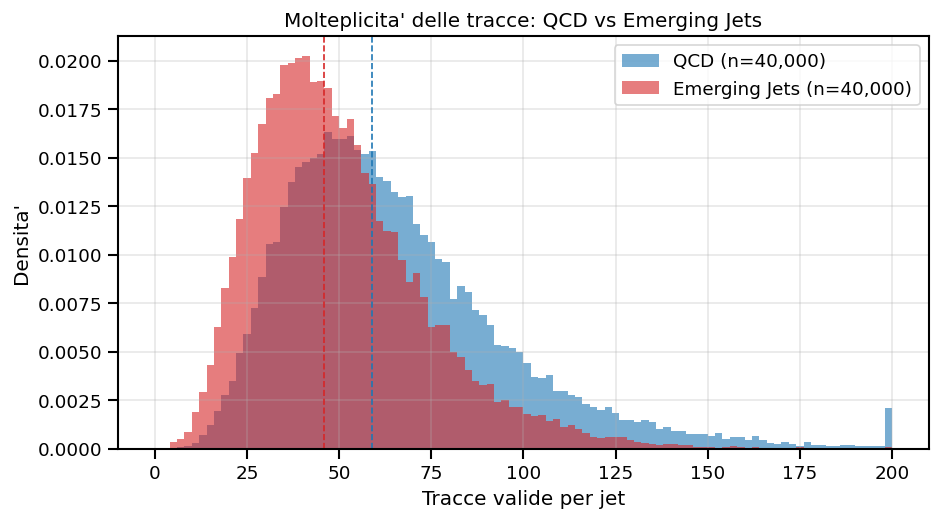

In [8]:
n_bkg = mask_bkg.sum(1)
n_sig = mask_sig.sum(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0, MAX_TRACKS + 2, 2)
ax.hist(n_bkg, bins=bins, density=True, alpha=0.6, color=COLOR_QCD, label=f"QCD (n={len(n_bkg):,})")
ax.hist(n_sig, bins=bins, density=True, alpha=0.6, color=COLOR_EJ, label=f"Emerging Jets (n={len(n_sig):,})")
ax.axvline(np.median(n_bkg), color=COLOR_QCD, ls="--", lw=1)
ax.axvline(np.median(n_sig), color=COLOR_EJ, ls="--", lw=1)
ax.set_xlabel("Tracce valide per jet"); ax.set_ylabel("Densita'")
ax.set_title("Molteplicita' delle tracce: QCD vs Emerging Jets")
ax.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "fig_multiplicity.png", bbox_inches="tight", dpi=150); plt.show()

### 5.2 Distribuzioni delle feature di traccia (normalizzate): QCD vs EJ
Sovrapponiamo le distribuzioni sulle tracce valide. Le feature che "separano" i due colori sono quelle
da cui il modello potra' imparare.

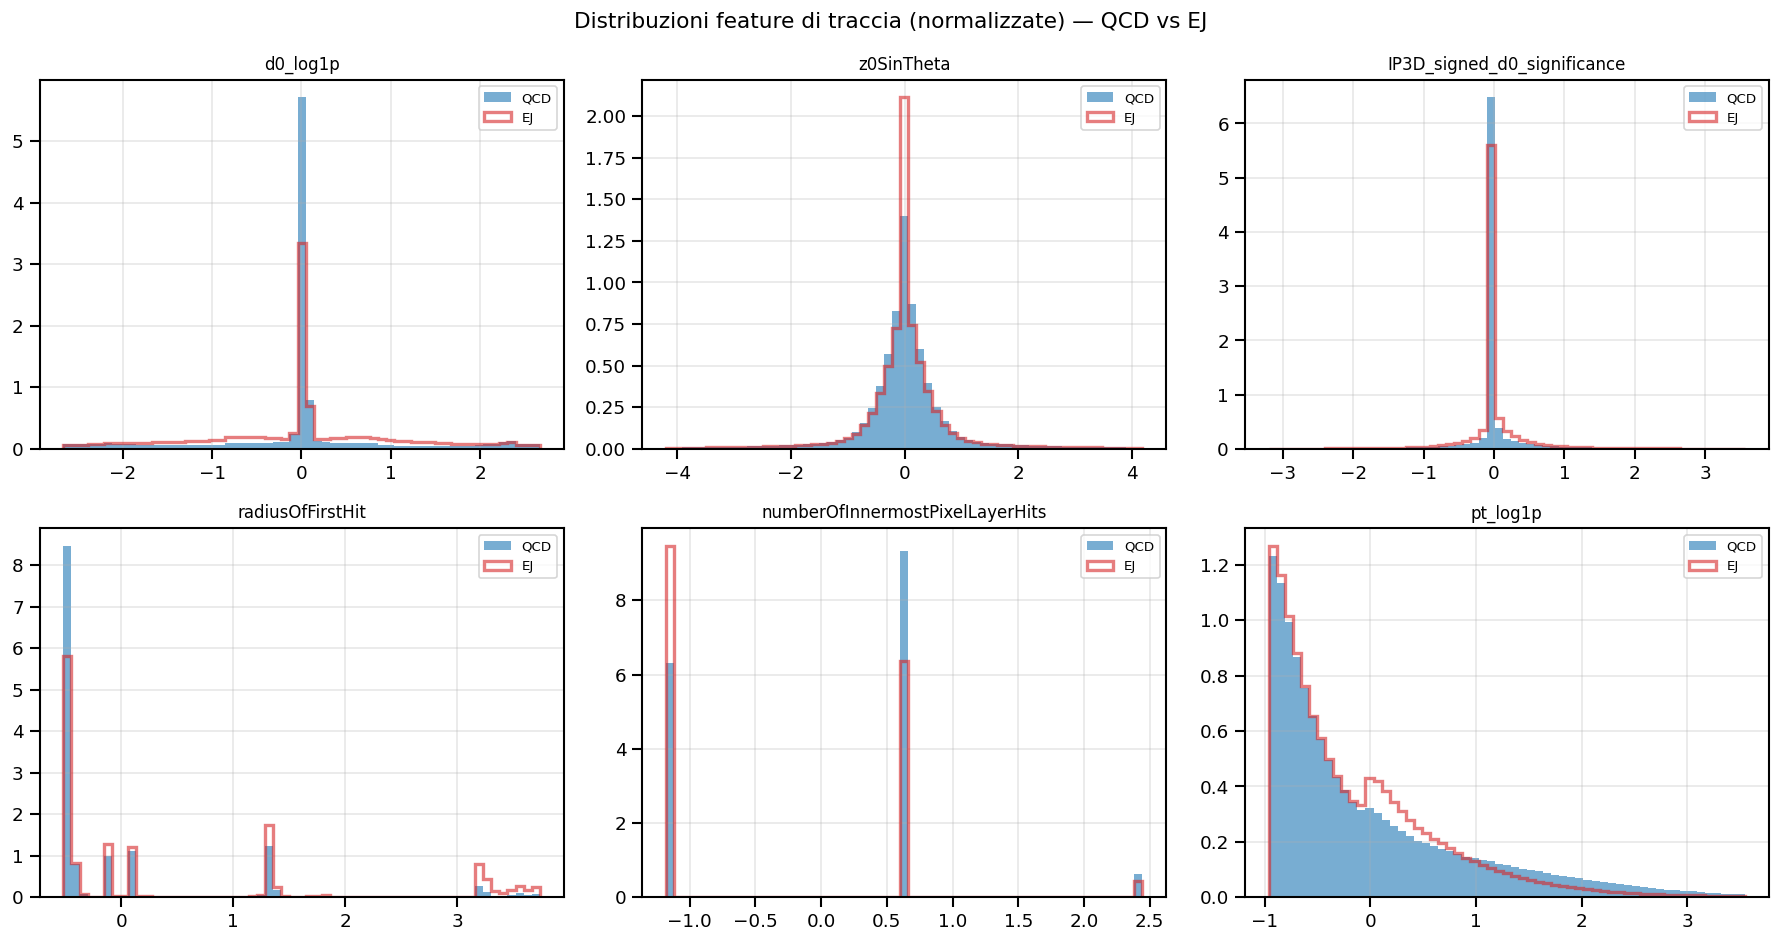

In [9]:
show = ["d0_log1p", "z0SinTheta", "IP3D_signed_d0_significance",
        "radiusOfFirstHit", "numberOfInnermostPixelLayerHits", "pt_log1p"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, show):
    j = TRACK_FEATURES.index(feat)
    b = Xt_bkg[:, :, j][mask_bkg]
    s = Xt_sig[:, :, j][mask_sig]
    lo, hi = np.percentile(np.concatenate([b, s]), [0.5, 99.5])
    bb = np.linspace(lo, hi, 60)
    ax.hist(b, bins=bb, density=True, alpha=0.6, color=COLOR_QCD, label="QCD")
    ax.hist(s, bins=bb, density=True, alpha=0.6, color=COLOR_EJ, histtype="step", lw=2, label="EJ")
    ax.set_title(feat, fontsize=10); ax.legend(fontsize=8)
fig.suptitle("Distribuzioni feature di traccia (normalizzate) — QCD vs EJ", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_track_distributions.png", bbox_inches="tight", dpi=150); plt.show()

### 5.3 Effetto del cleaning sul sentinella −999
Mostriamo `Tau21` PRIMA (dati grezzi, con il picco a −999) e DOPO il cleaning. Senza la gestione del
sentinella, quel picco diventerebbe un outlier a decine di σ.

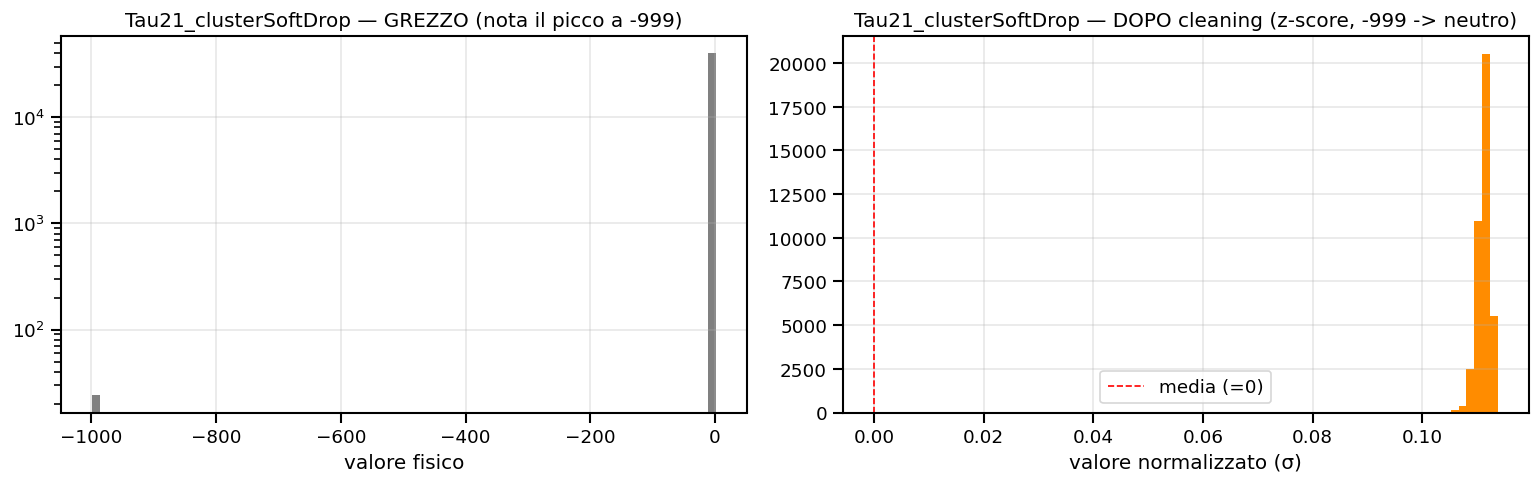

Frazione -999 nei dati grezzi: 0.060%


In [10]:
feat = "Tau21_clusterSoftDrop"
with h5py.File(SIG_FILE, "r") as f:
    raw = f["jets"][feat][:N_JETS].astype(np.float32)
j = JET_FEATURES.index(feat)
clean_vals = Xj_sig[:, j]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(raw, bins=80, color="gray")
axes[0].set_title(f"{feat} — GREZZO (nota il picco a -999)")
axes[0].set_xlabel("valore fisico"); axes[0].set_yscale("log")
axes[1].hist(clean_vals, bins=80, color="darkorange")
axes[1].axvline(0, color="red", ls="--", lw=1, label="media (=0)")
axes[1].set_title(f"{feat} — DOPO cleaning (z-score, -999 -> neutro)")
axes[1].set_xlabel("valore normalizzato (σ)"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_sentinel_cleaning.png", bbox_inches="tight", dpi=150); plt.show()
print(f"Frazione -999 nei dati grezzi: {(raw <= -100).mean():.3%}")

### 5.4 Matrice di correlazione (a livello di traccia): QCD, EJ e differenza
Aggreghiamo le tracce per jet (media sulle tracce valide) e calcoliamo la correlazione di Pearson fra
feature. **Non e' una decorrelazione dei dati**: e' una diagnostica per individuare ridondanze
(|ρ|>0.7) e capire quali coppie cambiano fra QCD ed EJ (pannello differenza).

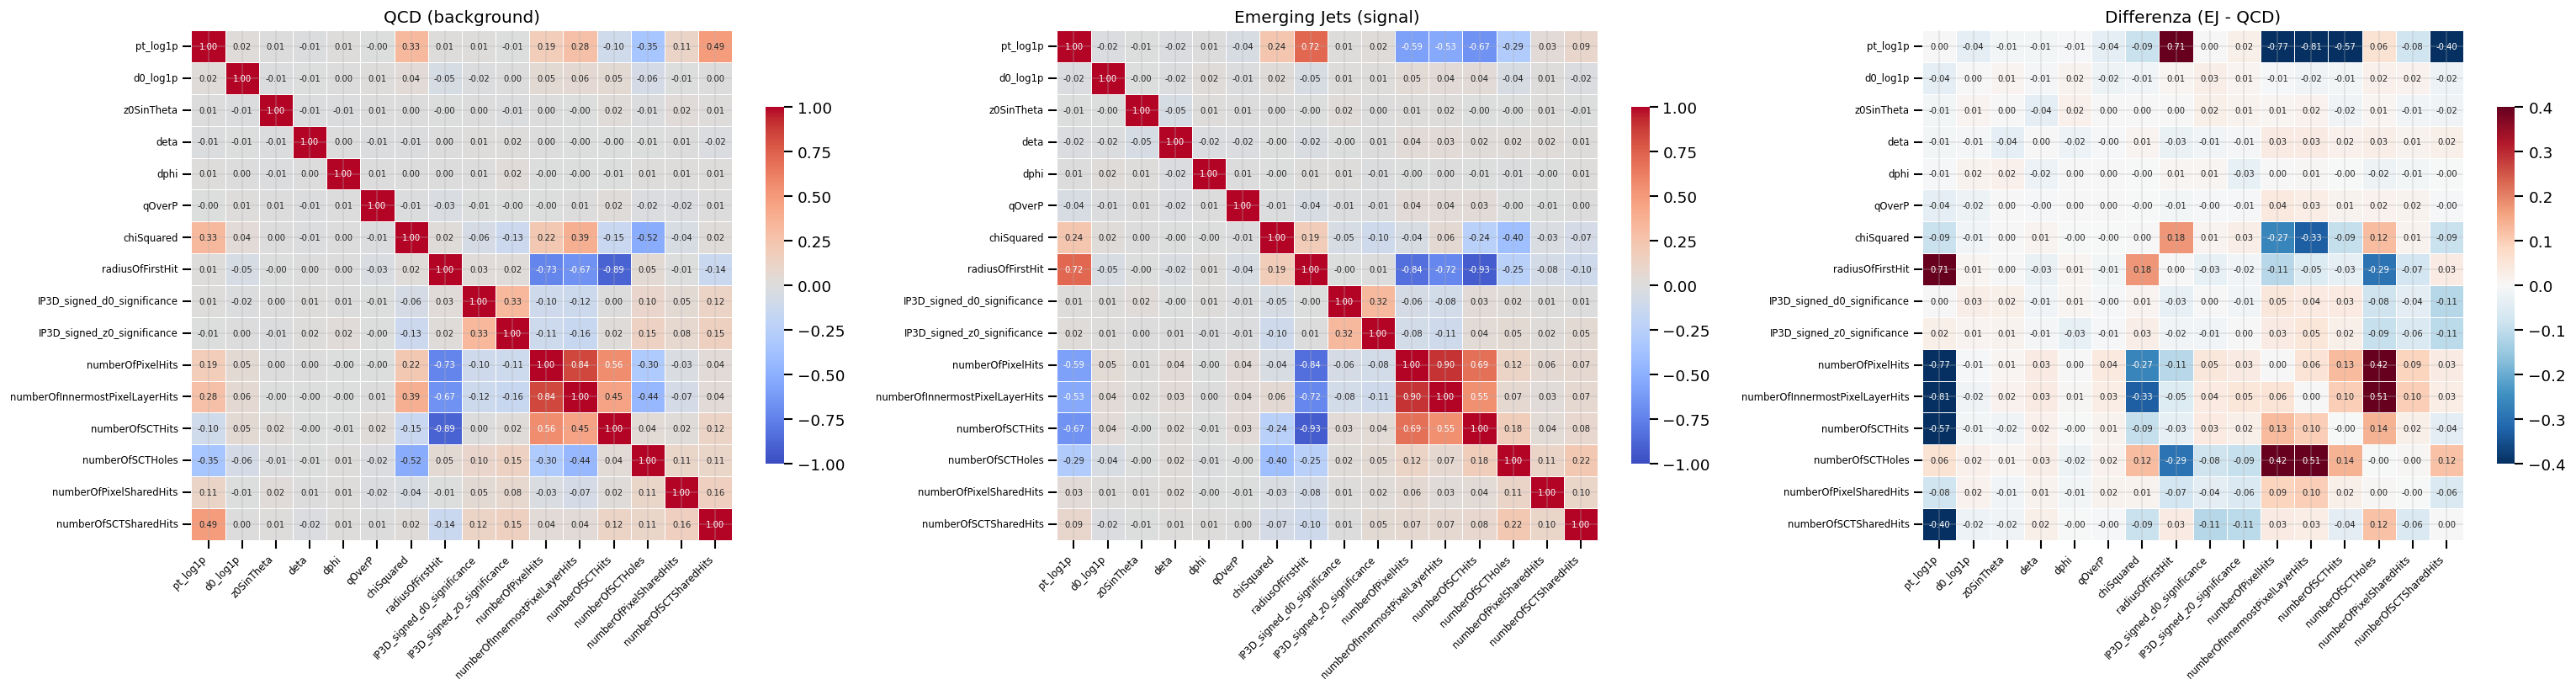

In [11]:
def agg_mean_per_jet(X, mask):
    keep = mask.sum(1) > 0
    Xk, mk = X[keep], mask[keep]
    m = mk[:, :, None].astype(np.float32)
    n = np.maximum(mk.sum(1, keepdims=True), 1).astype(np.float32)
    return (Xk * m).sum(1) / n

rng = np.random.default_rng(42)
def sub(X, mask, k=10_000):
    if len(X) <= k: return X, mask
    idx = rng.choice(len(X), k, replace=False); return X[idx], mask[idx]

c_bkg = np.corrcoef(agg_mean_per_jet(*sub(Xt_bkg, mask_bkg)).T)
c_sig = np.corrcoef(agg_mean_per_jet(*sub(Xt_sig, mask_sig)).T)
c_diff = c_sig - c_bkg

fig, axes = plt.subplots(1, 3, figsize=(26, 7))
for cm, axx, ttl, cmap, vlim in [
    (c_bkg, axes[0], "QCD (background)", "coolwarm", 1),
    (c_sig, axes[1], "Emerging Jets (signal)", "coolwarm", 1),
    (c_diff, axes[2], "Differenza (EJ - QCD)", "RdBu_r", 0.4)]:
    sns.heatmap(cm, ax=axx, annot=True, fmt=".2f", cmap=cmap, vmin=-vlim, vmax=vlim,
                xticklabels=TRACK_FEATURES, yticklabels=TRACK_FEATURES,
                linewidths=0.5, linecolor="white", annot_kws={"size": 6}, cbar_kws={"shrink": .7})
    axx.set_title(ttl, fontsize=12); axx.tick_params(labelsize=7)
    axx.set_xticklabels(axx.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_correlation.png", bbox_inches="tight", dpi=140); plt.show()

## 6. Rappresentazione 1 — Embedding aggregato (jet + statistiche tracce)

Per ogni jet costruiamo un vettore a lunghezza fissa:
- le **feature di jet** normalizzate;
- per ogni feature di traccia, **5 statistiche robuste** sulle tracce valide: `mean, std, median, q90, max`
  (mediana e 90° percentile rendono l'aggregato meno sensibile agli outlier — idea di Andrea);
- `log(1 + n_tracce)`.

E' l'input ideale per autoencoder/VAE con MLP.

In [12]:
def aggregate_tracks(X, mask):
    n_valid = mask.sum(1, keepdims=True).astype(np.float32)        # (N,1)
    valid = np.where(mask[:, :, None], X, np.nan)                  # padding -> nan
    mean   = np.nanmean(valid, axis=1)
    std    = np.nanstd(valid, axis=1)
    median = np.nanmedian(valid, axis=1)
    q90    = np.nanpercentile(valid, 90, axis=1)
    mx     = np.nanmax(valid, axis=1)
    out = np.concatenate([np.log1p(n_valid), mean, std, median, q90, mx], axis=1)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)  # jet vuoti -> 0

def build_embedding(Xj, Xt, mask):
    return np.concatenate([Xj, aggregate_tracks(Xt, mask)], axis=1).astype(np.float32)

AGG_NAMES = (JET_FEATURES + ["log_n_tracks"] +
             [f"{f}_{s}" for s in ["mean", "std", "median", "q90", "max"] for f in TRACK_FEATURES])
# NB: l'ordine sopra NON corrisponde alla concatenazione; ricostruiamo i nomi nell'ordine giusto:
AGG_NAMES = list(JET_FEATURES) + ["log_n_tracks"]
for s in ["mean", "std", "median", "q90", "max"]:
    AGG_NAMES += [f"{f}_{s}" for f in TRACK_FEATURES]

E_bkg = build_embedding(Xj_bkg, Xt_bkg, mask_bkg)
E_sig = build_embedding(Xj_sig, Xt_sig, mask_sig)

# Standardizzazione finale dell'embedding: fit SOLO sul QCD (train), applicata a entrambi
e_mean = E_bkg.mean(0, keepdims=True)
e_std  = np.maximum(E_bkg.std(0, keepdims=True), 1e-8)
E_bkg_n = ((E_bkg - e_mean) / e_std).astype(np.float32)
E_sig_n = ((E_sig - e_mean) / e_std).astype(np.float32)

print(f"Embedding: {E_bkg_n.shape[1]} dim/jet  =  {N_JF} jet + 1 + {N_TF}×5 track-stats")
assert len(AGG_NAMES) == E_bkg_n.shape[1]

Embedding: 96 dim/jet  =  15 jet + 1 + 16×5 track-stats


## 7. Diagnostica anti-leakage (la parte "scientifica")

Prima di addestrare qualunque modello, due controlli che dicono *quanto e' facile* il problema e
*da dove* arriva il potere discriminante. Servono a smascherare un'AUC alta dovuta a una sola feature
banale (o a un leakage).

- **AUC per singola feature**: ogni feature usata da sola come classificatore QCD-vs-EJ.
- **Logistic regression supervisionata**: baseline lineare con tutte le feature → tetto "facile" di
  separabilita'. Un autoencoder unsupervised dovrebbe avvicinarsi senza superarlo in modo sospetto.

In [13]:
y = np.concatenate([np.zeros(len(E_bkg_n)), np.ones(len(E_sig_n))])
X_all = np.concatenate([E_bkg_n, E_sig_n], axis=0)

rows = []
for i, name in enumerate(AGG_NAMES):
    a = roc_auc_score(y, X_all[:, i])
    rows.append((name, max(a, 1 - a)))   # max(a,1-a): direzione irrilevante
rows.sort(key=lambda r: r[1], reverse=True)

print("Top 15 feature per AUC singola:")
for name, a in rows[:15]:
    print(f"  {name:38s} AUC={a:.4f}")

# Baseline supervisionata
Xtr, Xte, ytr, yte = train_test_split(X_all, y, test_size=0.3, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=3000).fit(Xtr, ytr)
auc_lr = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
print(f"\nBaseline logistic regression (tutte le feature): AUC = {auc_lr:.4f}")

Top 15 feature per AUC singola:
  numberOfSCTSharedHits_mean             AUC=0.8750
  Tau2_clusterSoftDrop                   AUC=0.8723
  numberOfSCTSharedHits_std              AUC=0.8582
  Tau3_clusterSoftDrop                   AUC=0.8546
  Tau1_clusterSoftDrop                   AUC=0.8534
  numberOfInnermostPixelLayerHits_mean   AUC=0.8467
  radiusOfFirstHit_median                AUC=0.8424
  Tau4_clusterSoftDrop                   AUC=0.8391
  numberOfPixelHits_mean                 AUC=0.8294
  numberOfSCTSharedHits_q90              AUC=0.8231
  pt_log1p_std                           AUC=0.8159
  C2_clusterSoftDrop                     AUC=0.8159
  radiusOfFirstHit_mean                  AUC=0.8130
  numberOfPixelHits_median               AUC=0.8039
  pt_log1p_q90                           AUC=0.8003

Baseline logistic regression (tutte le feature): AUC = 0.9864


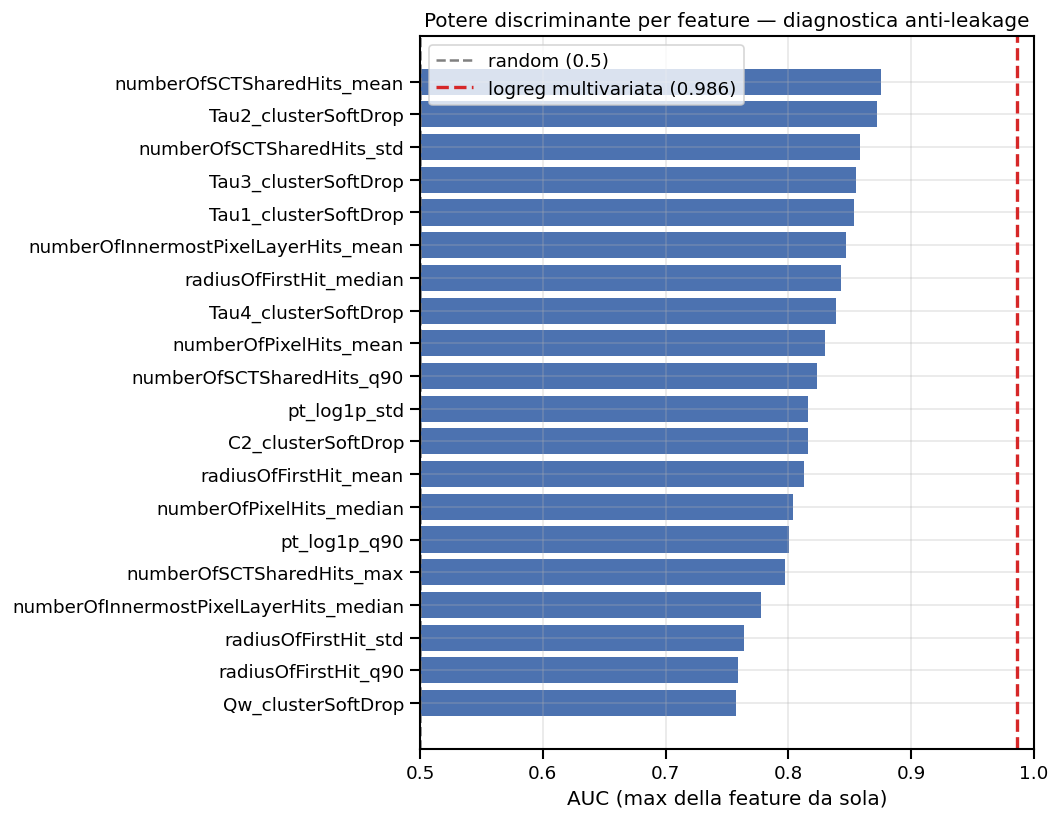

In [14]:
# Grafico: top-20 AUC per singola feature + linea della baseline
top = rows[:20]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh([t[0] for t in top][::-1], [t[1] for t in top][::-1], color="#4c72b0")
ax.axvline(0.5, color="gray", ls="--", label="random (0.5)")
ax.axvline(auc_lr, color=COLOR_EJ, ls="--", lw=2, label=f"logreg multivariata ({auc_lr:.3f})")
ax.set_xlabel("AUC (max della feature da sola)"); ax.set_xlim(0.5, 1.0)
ax.set_title("Potere discriminante per feature — diagnostica anti-leakage")
ax.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "fig_feature_auc.png", bbox_inches="tight", dpi=150); plt.show()

## 8. Rappresentazione 2 — Sequenze padded

Tensore `(N, MAX_TRACKS, F)` + maschera booleana. Le tracce sono **ordinate**: di default per `pt`
decrescente (ordine naturale), in alternativa per `|d0|` decrescente (mette le tracce displaced — la
firma EJ — nei primi slot, utile per RNN/Transformer).

In [15]:
def sort_tracks(X, mask, by="pt"):
    idx = TRACK_FEATURES.index("pt_log1p") if by == "pt" else TRACK_FEATURES.index("d0_log1p")
    key = (np.abs(X[:, :, idx]) if by == "d0" else X[:, :, idx]).copy()
    key[~mask] = -1e9                                   # padding sempre in fondo
    order = np.argsort(-key, axis=1)
    return (np.take_along_axis(X, order[:, :, None], axis=1),
            np.take_along_axis(mask, order, axis=1))

Xt_bkg_seq, mask_bkg_seq = sort_tracks(Xt_bkg, mask_bkg, by="pt")
Xt_sig_seq, mask_sig_seq = sort_tracks(Xt_sig, mask_sig, by="pt")
assert mask_bkg_seq[:, 0].all(), "lo slot 0 deve essere sempre occupato dopo l'ordinamento"
print("Sequenze:", Xt_bkg_seq.shape, "| padding:",
      f"{(~mask_bkg_seq).mean()*100:.1f}% degli slot")

Sequenze: (40000, 200, 16) | padding: 67.6% degli slot


### 8.1 Struttura del padding e della maschera

Ogni jet ha un numero **diverso** di tracce, ma il tensore della Rappresentazione 2 ha sempre 200 slot:
i posti in eccesso sono **padding** (zeri) che la **maschera** dice al modello di ignorare. Ordinando
alcuni jet per numero di tracce si vede la tipica forma "a scala" — ed e' subito evidente che gli
Emerging Jets riempiono piu' slot dei QCD (piu' tracce = firma di molti vertici displaced).

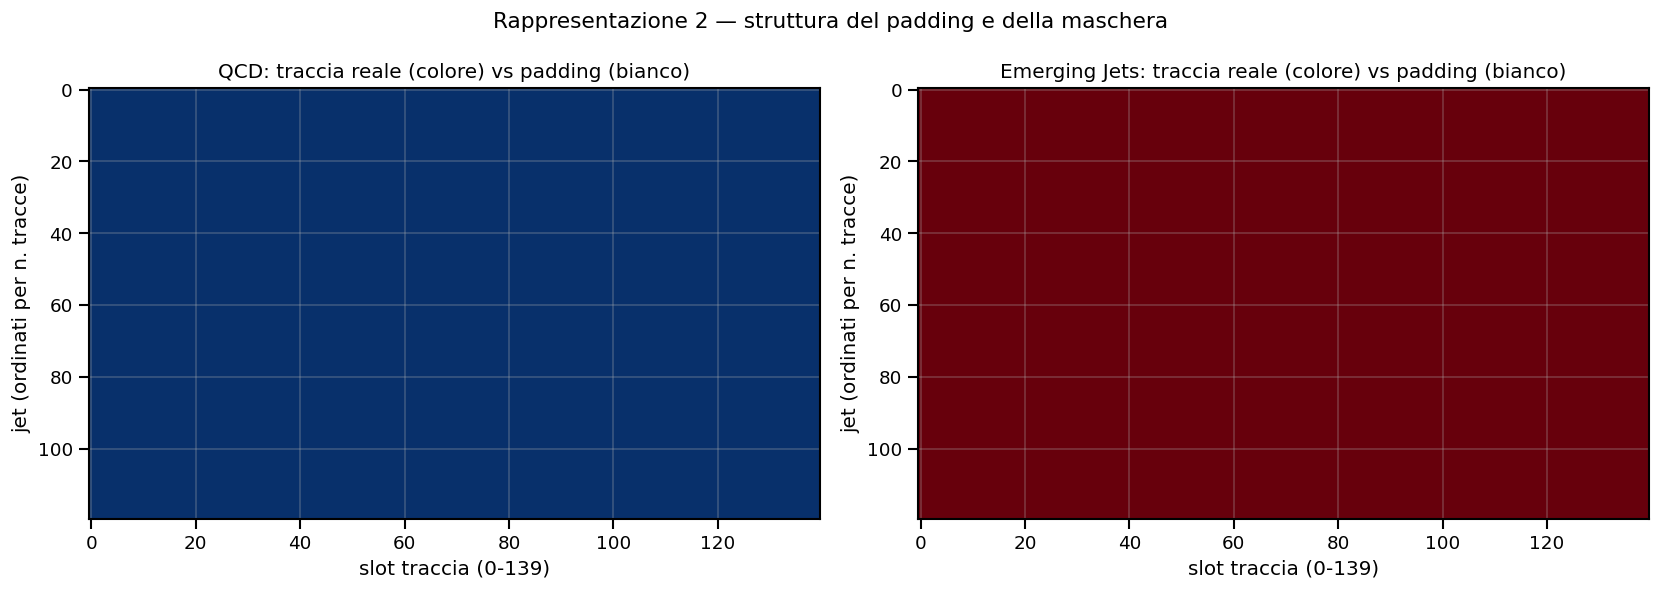

In [16]:
# "Occupato vs padding": 120 jet (righe) × primi 140 slot (colonne), ordinati per
# numero di tracce. Colore = traccia reale, bianco = padding. La maschera e' esattamente questa.
N_SHOW_JETS, N_SHOW_SLOTS = 120, 140
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mk, ttl, cmap in [(axes[0], mask_bkg, "QCD", "Blues"),
                          (axes[1], mask_sig, "Emerging Jets", "Reds")]:
    order = np.argsort(-mk.sum(1))[:N_SHOW_JETS]          # dal jet piu' affollato
    occ = mk[order][:, :N_SHOW_SLOTS]
    ax.imshow(occ, aspect="auto", cmap=cmap, interpolation="none", vmin=0, vmax=1)
    ax.set_xlabel(f"slot traccia (0-{N_SHOW_SLOTS-1})")
    ax.set_ylabel("jet (ordinati per n. tracce)")
    ax.set_title(f"{ttl}: traccia reale (colore) vs padding (bianco)")
fig.suptitle("Rappresentazione 2 — struttura del padding e della maschera", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_padding_structure.png", bbox_inches="tight", dpi=150); plt.show()

## 9. Rappresentazione 3 — Grafi kNN

Ogni jet diventa un grafo: **nodi** = tracce valide, **archi** = k vicini piu' prossimi. Costruiamo i
grafi in **due spazi** complementari:
- **η–φ**: vicinanza spaziale nel calorimetro (struttura di sub-jet);
- **(IP3D d0 sig, IP3D z0 sig)**: tracce dallo stesso vertice displaced finiscono vicine → connette
  preferenzialmente i costituenti di un decadimento secondario (la firma EJ).

Se PyTorch Geometric non e' installato, i grafi vengono salvati come dizionari numpy.

In [17]:
def build_knn_graph(x_jet, mask_jet, space="etaphi", k=KNN_K):
    vi = np.where(mask_jet)[0]
    n = len(vi)
    if n == 0:
        return None
    xv = x_jet[vi]
    if space == "etaphi":
        cols = [TRACK_FEATURES.index("deta"), TRACK_FEATURES.index("dphi")]
    else:
        cols = [TRACK_FEATURES.index("IP3D_signed_d0_significance"),
                TRACK_FEATURES.index("IP3D_signed_z0_significance")]
    coords = xv[:, cols]
    k_eff = min(k, n - 1)
    if k_eff <= 0:
        src = dst = np.array([0]); ea = np.zeros((1, 2), np.float32)
    else:
        nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(coords)
        _, ind = nn.kneighbors(coords)
        src = np.repeat(np.arange(n), k_eff)
        dst = ind[:, 1:].flatten()                       # esclude se stesso
        ea = (coords[dst] - coords[src]).astype(np.float32)
    if HAS_PYG:
        return Data(x=torch.tensor(xv, dtype=torch.float32),
                    edge_index=torch.tensor(np.stack([src, dst]), dtype=torch.long),
                    edge_attr=torch.tensor(ea, dtype=torch.float32), num_nodes=n)
    return {"x": xv, "edge_index": np.stack([src, dst]), "edge_attr": ea, "num_nodes": n}

def build_graphs(X, mask, space="etaphi", k=KNN_K, limit=N_GRAPH_DEMO):
    out = []
    for i in range(min(limit, len(X))):
        g = build_knn_graph(X[i], mask[i], space, k)
        if g is not None:
            out.append(g)
    return out

graphs_bkg = build_graphs(Xt_bkg, mask_bkg, space="etaphi")
graphs_sig = build_graphs(Xt_sig, mask_sig, space="etaphi")
print(f"Grafi η-φ costruiti: QCD={len(graphs_bkg):,} | EJ={len(graphs_sig):,} | PyG={HAS_PYG}")

Grafi η-φ costruiti: QCD=4,000 | EJ=4,000 | PyG=True


### 9.1 Visualizzazione dei grafi: QCD vs Emerging Jet

Mostriamo un grafo per tipo nello spazio η–φ. **Il modello si allena sul QCD** (sinistra): impara a
"ricostruire" la struttura tipica di un jet ordinario. L'Emerging Jet (destra) e' cio' che vogliamo
riconoscere come anomalo — tipicamente piu' tracce e una geometria diversa.

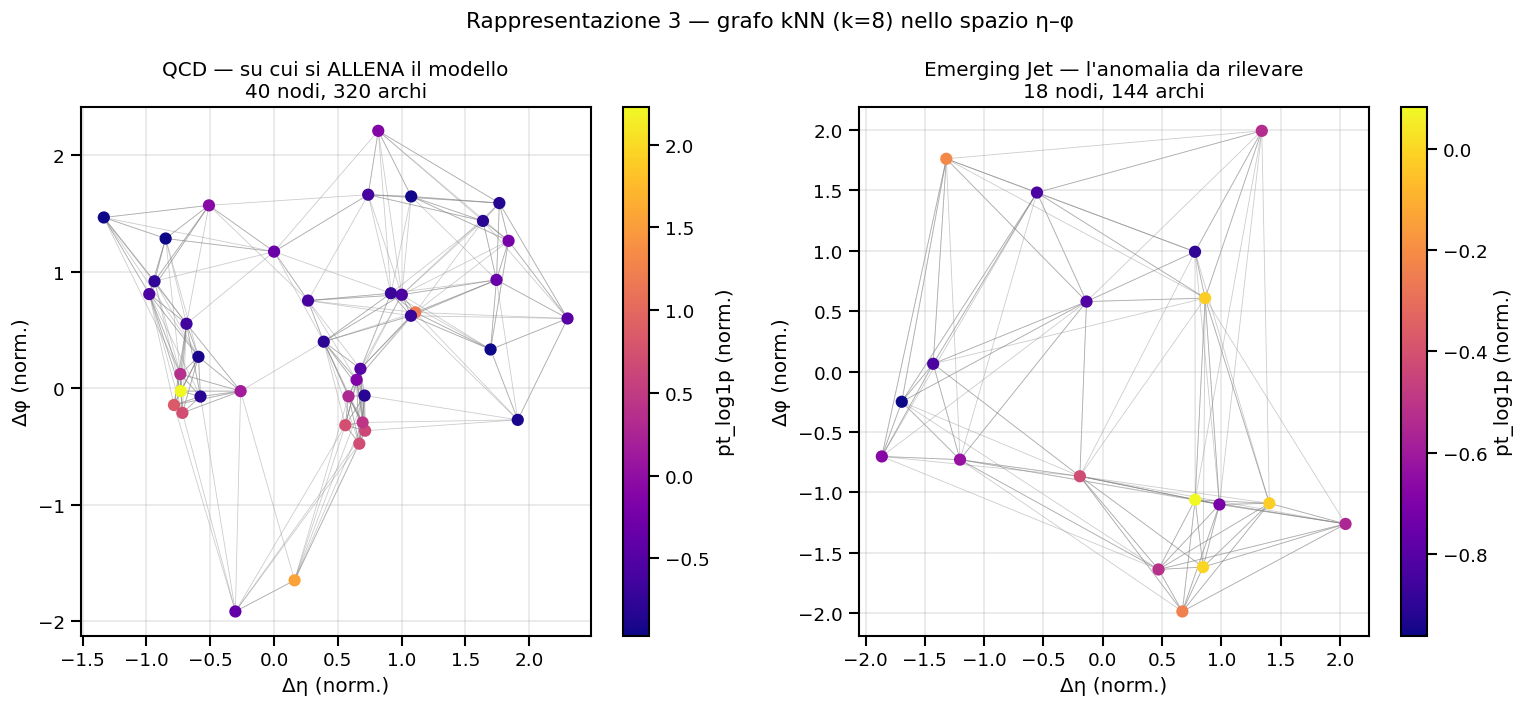

In [18]:
def get(g, key):
    if HAS_PYG:
        return g.x.numpy() if key == "x" else g.edge_index.numpy()
    return g[key]

de, dp = TRACK_FEATURES.index("deta"), TRACK_FEATURES.index("dphi")
pti = TRACK_FEATURES.index("pt_log1p")

def readable(glist):
    # primo grafo con un numero di nodi "leggibile" per il disegno
    for g in glist:
        if 15 <= get(g, "x").shape[0] <= 50:
            return g
    return glist[0] if glist else None

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, glist, ttl in [(axes[0], graphs_bkg, "QCD — su cui si ALLENA il modello"),
                       (axes[1], graphs_sig, "Emerging Jet — l'anomalia da rilevare")]:
    g = readable(glist)
    if g is None:
        continue
    xg, ei = get(g, "x"), get(g, "edge_index")
    for s, d in zip(ei[0], ei[1]):
        ax.plot([xg[s, de], xg[d, de]], [xg[s, dp], xg[d, dp]],
                color="gray", lw=0.5, alpha=0.4, zorder=1)
    sc = ax.scatter(xg[:, de], xg[:, dp], c=xg[:, pti], cmap="plasma", s=40, zorder=2)
    plt.colorbar(sc, ax=ax, label="pt_log1p (norm.)")
    ax.set_xlabel("Δη (norm.)"); ax.set_ylabel("Δφ (norm.)")
    ax.set_title(f"{ttl}\n{xg.shape[0]} nodi, {ei.shape[1]} archi")
fig.suptitle(f"Rappresentazione 3 — grafo kNN (k={KNN_K}) nello spazio η–φ", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_knn_graph.png", bbox_inches="tight", dpi=150); plt.show()

## 10. Salvataggio delle rappresentazioni

Tutto in `FINAL/processed/`. I notebook dei modelli caricheranno questi file senza rifare il preprocessing.

In [19]:
# Rappr. 1 — embedding aggregato (standardizzato)
np.savez_compressed(OUT_DIR / "repr1_aggregate.npz",
                    bkg=E_bkg_n, sig=E_sig_n, feature_names=np.array(AGG_NAMES, dtype=object))
# Rappr. 2 — sequenze padded
np.savez_compressed(OUT_DIR / "repr2_sequences.npz",
                    X_bkg=Xt_bkg_seq, mask_bkg=mask_bkg_seq,
                    X_sig=Xt_sig_seq, mask_sig=mask_sig_seq,
                    feature_names=np.array(TRACK_FEATURES, dtype=object))
# Rappr. 3 — grafi
if HAS_PYG:
    torch.save({"bkg": graphs_bkg, "sig": graphs_sig}, OUT_DIR / "repr3_graphs.pt")
else:
    np.savez_compressed(OUT_DIR / "repr3_graphs.npz",
                        bkg=np.array(graphs_bkg, dtype=object),
                        sig=np.array(graphs_sig, dtype=object))
print("Salvato in:", OUT_DIR)
for p in sorted(OUT_DIR.glob("repr*")):
    print("  -", p.name, f"({p.stat().st_size/1e6:.1f} MB)")

Salvato in: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\FINAL\processed
  - repr1_aggregate.npz (24.0 MB)
  - repr2_sequences.npz (191.2 MB)
  - repr3_graphs.pt (129.5 MB)


## 11. Riepilogo

| Rappresentazione | Shape | Modelli |
|---|---|---|
| 1 — Aggregato | `(N, n_jet + 1 + n_track×5)` | AE / VAE (MLP) |
| 2 — Sequenze | `(N, 200, n_track)` + mask | RNN / LSTM / Transformer / AE seq |
| 3 — Grafi kNN | lista di grafi (η–φ, impact) | GNN / Graph-AE |

**Scelte chiave:** stats dei supervisori · gestione esplicita del −999 · clip ±10σ a priori (anti-leak) ·
feature jet+track · diagnostica AUC singola + baseline logistic regression · niente feature di leakage.

In [20]:
print("="*60)
print("PREPROCESSING FINALE — RIEPILOGO")
print("="*60)
print(f"QCD (train): {len(E_bkg_n):,} jet  |  EJ (eval): {len(E_sig_n):,} jet")
print(f"Repr.1 aggregato : {E_bkg_n.shape}")
print(f"Repr.2 sequenze  : {Xt_bkg_seq.shape}  (padding {(~mask_bkg_seq).mean()*100:.1f}%)")
print(f"Repr.3 grafi     : {len(graphs_bkg):,} QCD / {len(graphs_sig):,} EJ")
print(f"Baseline logreg AUC: {auc_lr:.4f}  (riferimento per i modelli unsupervised)")

PREPROCESSING FINALE — RIEPILOGO
QCD (train): 40,000 jet  |  EJ (eval): 40,000 jet
Repr.1 aggregato : (40000, 96)
Repr.2 sequenze  : (40000, 200, 16)  (padding 67.6%)
Repr.3 grafi     : 4,000 QCD / 4,000 EJ
Baseline logreg AUC: 0.9864  (riferimento per i modelli unsupervised)
